In [2]:
conda activate omfitenv


Note: you may need to restart the kernel to use updated packages.


In [3]:
#%pip install --upgrade omfit_classes

In [4]:
#%pip install omas

In [5]:
from omfit_classes import omfit_eqdsk

In [6]:
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from uncertainties import ufloat
import numpy as np
from scipy.integrate import cumtrapz
from scipy.constants import mu_0
import os

gfile average = 518598.29013005795
ffile average= 487331.5782329948


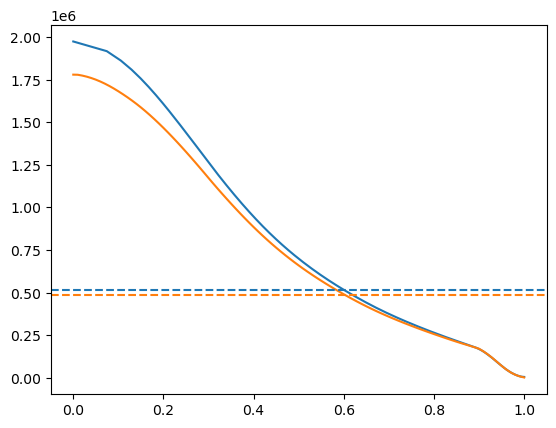

In [8]:
#volume average
def vol_avg(geqdsk, prof, rho_prof = None): #rho_prof is only specified if integrating a quantity outside the geqdsk
    if rho_prof is not None:
        rho_geqdsk = geqdsk['RHOVN'] 
        prof_sized = np.interp(rho_geqdsk,rho_prof,prof)
        prof_sized_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof_sized)[-1]
        prof_sized_vol_avg = prof_sized_vol_int/omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], 1)[-1]
        return prof_sized_vol_avg
    
    else:
        prof_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof)[-1]
        prof_vol_avg = prof_vol_int/omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], 1)[-1]
        return prof_vol_avg

#H factor definitions
def vol_integral(geqdsk, prof, rho_prof = None): #rho_prof is only specified if integrating a quantity outside the geqdsk
    if rho_prof is not None:
        rho_geqdsk = geqdsk['RHOVN']
        prof_sized = np.interp(rho_geqdsk,rho_prof,prof)
        prof_sized_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof_sized)[-1]
        return prof_sized_vol_int
    
    else:
        prof_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof)[-1]
        return prof_vol_int

def taue_h_mode(x,a1=0.93,a2=0.15,a3=0.41,a4=-0.69,a5=1.97,a6=0.78,a7=0.58): #M = 2.5 for DT
    h_mode_vars = [x['ip'],x['bcentr'],x['density'],x['ptot_cps'],x['rsurf'],x['kappa'],x['eps']]
    return 0.0562*2.5**(0.19)*np.prod(np.power(h_mode_vars,np.array([a1,a2,a3,a4,a5,a6,a7])))

def taue_l_mode(x,a1=0.85,a2=1.2,a3=0.3,a4=0.5,a5=0.1,a6=0.2,a7=-0.5): #M = 2.5 for DT
    l_mode_vars = [x['ip'],x['rsurf'],x['aminor'],x['kappa'],x['density']/10,x['bcentr'],x['ptot_cps']] #this scaling law uses n20
    return 0.048*2.5**(0.5)*np.prod(np.power(x,np.array([a1,a2,a3,a4,a5,a6,a7])),axis=1)

def get_params_dict(gfile,ffile):
    ip = abs(ffile['ip'][-1])
    bt = abs(ffile['b0'][-1])
    
    rho_tor_norm = ffile['rho'][:]
    e_density_profile = ffile['ne'][-1] #10^19
    density_19_avg = vol_avg(gfile,e_density_profile,rho_tor_norm)
    
    Palpha = (ffile['pfuse'][-1] + ffile['pfusi'][-1]) #multiply by 5 would give fusion power, don't do for this
    Ptot = ffile['prfe'][-1] + ffile['prfi'][-1] + Palpha
    Rmaj = gfile['fluxSurfaces']['geo']['R'][-1]
    kappa = gfile['fluxSurfaces']['geo']['kap'][-1]
    aminor = gfile['fluxSurfaces']['geo']['a'][-1]
    eps = gfile['fluxSurfaces']['geo']['eps'][-1]
    params_dict = {'ip':ip,'bcentr':bt,'density':density_19_avg,'ptot_cps':Ptot,'rsurf':Rmaj,'kappa':kappa,'eps':eps,'aminor':aminor}
    return params_dict

def calc_H98y2(gfile,ffile):
    rho = ffile['rho'][:]
    ne_prof = ffile['ne'][-1,:] #10^19/m^3
    Te_prof = ffile['te'][-1,:] #keV
    ni_prof_tot = ffile['ni'][-1,:] + ffile['nz0'][-1,:] + ffile['nhe'][-1,:]
    Ti_prof = ffile['ti'][-1,:]
    total_pressure = (ne_prof*Te_prof+ni_prof_tot*Ti_prof)*1602.2  #to convert to Pa (multiplication is for from eV to Joules)
    
    Wthr = vol_integral(gfile,(3/2)*total_pressure,rho)/1e6 #MJ
    #print('Wthr =',Wthr)

    params_dict = get_params_dict(gfile,ffile)
    #print(params_dict)
    tau_H98y2 = taue_h_mode(params_dict,a1=0.93,a2=0.15,a3=0.41,a4=-0.69,a5=1.97,a6=0.78,a7=0.58)
    #print('tau_H98y2 =',tau_H98y2)
    tau_E = Wthr/params_dict['ptot_cps']
    #print('tau_E =',tau_E)
    H98y2 = tau_E/tau_H98y2
    #print('H98y2 =',H98y2)

    return H98y2

ffile0 = '/pscratch/sd/h/hswils/github_repos/MANTA_DBSCANS/basecase/SCAN/work/fastran_tr_fastran_7/fastran.nc'
gfile0 = '/pscratch/sd/h/hswils/github_repos/MANTA_DBSCANS/basecase/SCAN//work/fastran_tr_fastran_7/g000001.00001'

rootgrp = Dataset(ffile0)
geqdsk = omfit_eqdsk.OMFITeqdsk(gfile0)

pres_g = geqdsk['PRES']
print('gfile average =',vol_avg(geqdsk,pres_g))

rho = rootgrp['rho'][:]
ne_prof = rootgrp['ne'][-1,:] #10^19/m^3
Te_prof = rootgrp['te'][-1,:] #keV
ni_prof_tot = rootgrp['ni'][-1,:] + rootgrp['nz0'][-1,:] + rootgrp['nhe'][-1,:]
Ti_prof = rootgrp['ti'][-1,:]
p_prof = (ne_prof*Te_prof+ni_prof_tot*Ti_prof)*1602.2 #to convert to Pa (multiplication is for from eV to Joules)
print('ffile average=',vol_avg(geqdsk,p_prof,rho))
  
plt.plot(geqdsk['RHOVN'],pres_g,color = 'tab:blue')
plt.plot(rho,p_prof,color = 'tab:orange')
plt.axhline(vol_avg(geqdsk,pres_g),color = 'tab:blue',linestyle = 'dashed')
plt.axhline(vol_avg(geqdsk,p_prof,rho),color = 'tab:orange',linestyle = 'dashed')
plt.show()





fGr = 0.8271998049287385


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


H98y2 = 0.8265060668973244
26.18132427
0.19999999999999998
fail
1.461+/-0.016
1.4050022971131673


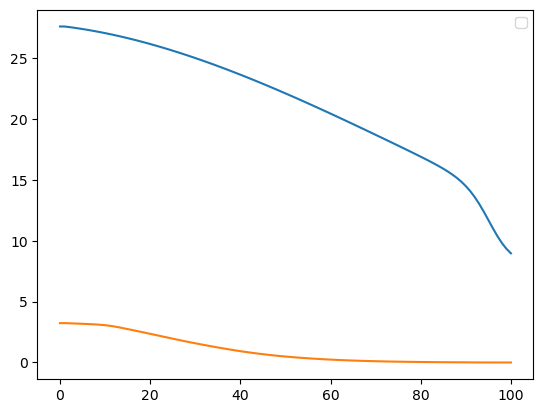

In [11]:
cwd = os.getcwd()
SCAN_dir = cwd+'/SCAN'

## First just find the fastran.nc and geqdsk file
work_dir = SCAN_dir+'/'+'/work'
fastran_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_tr_')]
ffile = work_dir+'/'+fastran_dir[0]+'/fastran.nc'
gfile = work_dir+'/'+fastran_dir[0]+'/g000001.00001'

rootgrp = Dataset(ffile)
geqdsk = omfit_eqdsk.OMFITeqdsk(gfile)

## Some ffile variables
Rmaj = float(rootgrp['r0'][-1])
Bt = float(rootgrp['b0'][-1])
Ip = rootgrp['ip'][-1]
aminor = rootgrp['a0'][-1]

## Calculate Greenwald fraction
nebar = rootgrp['nebar'][-1]
n_Gr = Ip/(np.pi*aminor**2)
f_Gr = nebar/10/n_Gr #divide by 10 to switch from 10^19 to 10^20
print('fGr =',f_Gr)

## Calculate H factor
print('H98y2 =',calc_H98y2(geqdsk,rootgrp))

## Calculate Angioni peaking
Gamma_NBI = 0

#Grab profiles
rho = rootgrp['rho'][:]
#if sim in ['simulation_641737_0000','simulation_641737_0001','simulation_641737_0002']:
ne_prof = rootgrp['ne'][-1,:] #10^19/m^3
Te_prof = rootgrp['te'][-1,:] #keV
ni_prof_tot = rootgrp['ni'][-1,:] + rootgrp['nz0'][-1,:] + rootgrp['nhe'][-1,:]
Ti_prof = rootgrp['ti'][-1,:]
p_prof = (ne_prof*Te_prof+ni_prof_tot*Ti_prof) #should be in keV*10**19/m**3 for Angioni beta equation  #*1602.2 to convert to Pa (multiplication is for from eV to Joules)

plt.plot(ne_prof)
plt.plot(ni_prof_tot)

##compare pressures from g and f files
#plt.plot(rho,p_prof*1602.2)
#plt.plot(rho_geqdsk,pres_geqdsk)
# pres_f_vol_avg = vol_avg(geqdsk['fluxSurfaces'],p_prof*1602.2,rho)
# print(pres_g_vol_avg)
# print(pres_f_vol_avg)

#Calculate volume averages   
ne_vol_avg = vol_avg(geqdsk,ne_prof,rho)
p_vol_avg = vol_avg(geqdsk,p_prof,rho)
Te_vol_avg = vol_avg(geqdsk,Te_prof,rho)

#Calculate regression variables
nu_eff = 0.2*ne_vol_avg*Rmaj/(Te_vol_avg**2) #don't use line average for this density average
beta = 4.02e-3*p_vol_avg/(Bt**2)

n02 = ne_prof[int(0.2*len(ne_prof))]
print(n02)
print(rho[int(0.2*len(rho))])

#Calculate Angioni peaking
npeaking = ufloat(1.347,0.014) - ufloat(0.117,0.005)*np.log(nu_eff) + ufloat(1.331,0.117)*Gamma_NBI - ufloat(4.030,0.810)*beta
#npeaking_fgrR = ufloat(1.253,0.037) - ufloat(0.499,0.030)*f_Gr + ufloat(2.094,0.137)*Gamma_NBI - ufloat(0.117,0.009)*Rmaj


n_peak_left = npeaking.nominal_value-npeaking.std_dev
n_peak_right = npeaking.nominal_value+npeaking.std_dev
if n02/ne_vol_avg >= n_peak_left and n02/ne_vol_avg <= n_peak_right:
    print('pass')
else:
    print('fail')
print(npeaking)
print(n02/ne_vol_avg) #volume average NOT line average

plt.legend()
plt.show()   
#print(rootgrp.variables)